In [1]:

# Data Normalization Techniques
#
# In this lab we'll learn about various data normalization techniques, with
# both their implementation and commonly used library functions:
#
# 1. Min-max normalization
# 2. Z-score normalization
# 3. Decimal Scaling Normalization

# Data Normalization Techniques Lab

This lab explores three common data normalization techniques: Min-Max scaling, Z-Score normalization, and Decimal Scaling. You will learn how to implement each technique manually and also how to use the corresponding functions from the scikit-learn library for Min-Max and Z-Score normalization. The lab demonstrates these techniques using the "LotArea" column from a housing dataset.

In [2]:
# Download the dataset file to local storage to current directory (from publicly
# shared drive file)
#
# Original source:
# https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques
!gdown 1Yhw8tBCmjYrDZ5Rm1xPrP2y5bmBmxoEP

Downloading...
From: https://drive.google.com/uc?id=1Yhw8tBCmjYrDZ5Rm1xPrP2y5bmBmxoEP
To: /content/housing.csv
100% 461k/461k [00:00<00:00, 106MB/s]


In [3]:
# Import required libraries
import pandas as pd

from sklearn.preprocessing import MinMaxScaler # min-max
from sklearn.preprocessing import StandardScaler # z-score
import math # used to calculate no. of digits (floor, log) for decimal scaling

In [4]:
import pandas as pd

# Load the dataset file into memory
DATASET_PATH = "./housing.csv"
df = pd.read_csv(DATASET_PATH)
df

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


In [5]:
# 1. Min-max normalization
#
# Min-max normalization is a normalization technique where we consider the
# original scale of the data as the min and max values of the attribute
# and scale all its values to a given range (a to b ; where a < b)

In [6]:
new_df = df["LotArea"].sort_values()
new_df

,LotArea
956,1300
1039,1477
614,1491
489,1526
1038,1533
...,...
451,70761
706,115149
249,159000
335,164660


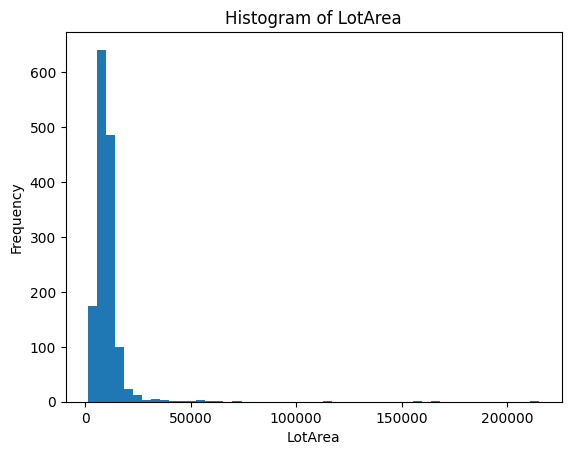

In [7]:
import matplotlib.pyplot as plt
def plot(p_df):
  # Let's plot a histogram for the 'LotArea' column  plt.figure(figsize=(10, 6))
  p_df.hist(bins=50)
  plt.title('Histogram of LotArea')
  plt.xlabel('LotArea')
  plt.ylabel('Frequency')
  plt.grid(False)
  plt.show()

plot(new_df)

In [8]:
# Let us consider the LotArea column
A = df["LotArea"]

# Calculating the column's minimum and maximum value
minA = A.min()
maxA = A.max()

# Displaying the current min-max values
print("Current min:", minA)
print("Current max:", maxA)

Current min: 1300
Current max: 215245


In [9]:
# As we can see here, the range of value here is really high and it would be
# better if we normalize this column

# Calculating the range/difference of min-max
rangeA = maxA - minA

# Choosing a new min/max scale
newMin = 1
newMax = 100

# Normalizing the value between newMin and newMax
#
# All values of df are subtracted by minA then divided by rangeA, the resulting
# values then get multiplied by newMax-newMin and added to newMin

# Formula
# v' = ((v-minA)/rangeA) * (newMax - newMin) + newMin
A_normalized = ((df["LotArea"] - minA) / rangeA) * (newMax - newMin) + newMin

# Confirming that the min/max values have been followed
print("New min:", A_normalized.min())
print("New max:", A_normalized.max())

# Displaying the normalized output
A_normalized

# A simple intuitive explanation for the working of min-max normalization -
#
# Take a rough number line on a sheet and mark points to visualize and
# intuitively understand the above equation better:
#
# Start with roughly marking the the absolute min and max and mark a point
# between the min and max to denote the value, in our case of df["LotArea"]
#
# df["LotArea"] - minA -> How far is the value from its attribute's min
#
# rangeA -> The maximum possible value for (df["LotArea"] - minA)
#
# df["LotArea"] - minA) / rangeA -> The normalized value of the attribute b/w
# 0 and 1
#
# (newMax - newMin) -> Multiplying the normalized values between 0 and 1
# gives us the values for the new range of values
#
# The new range would be between 0 and newMax after multiplication, therefore
# adding newMin to fix that

New min: 1.0
New max: 100.0


,LotArea
0,4.308561
1,4.840707
2,5.604221
3,4.817570
4,6.997055
...,...
1455,4.061922
1456,6.494987
1457,4.582500
1458,4.894847


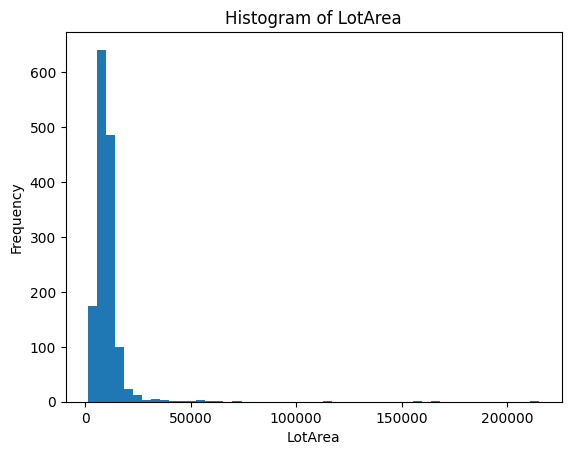

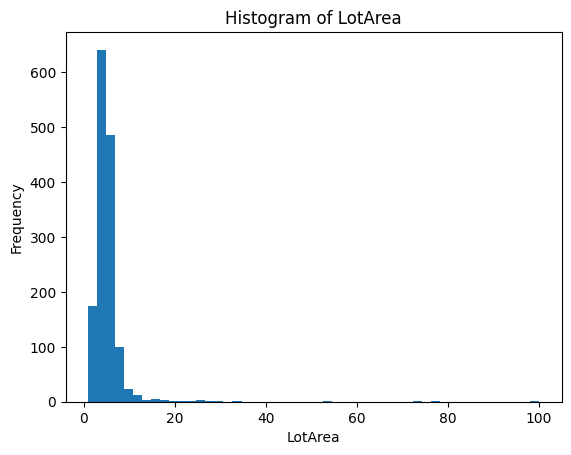

In [10]:
plot(new_df)
plot(A_normalized)

In [11]:
A.to_frame()
A

,LotArea
0,8450
1,9600
2,11250
3,9550
4,14260
...,...
1455,7917
1456,13175
1457,9042
1458,9717


In [12]:
# @title
# Self-exploration: You could pick a different column such as the "Year" column,
# where it might make more sense to have a normalized scale for prediction than
# a value such as 2000 or 1900 for example

# ...
B = df['YrSold']

minB = B.min()
maxB = B.max()

print(f"Current Min: {minB}\nCurrent Max: {maxB}")

rangeB = maxB - minB

B_normalized = ((df['YrSold']-minB)/rangeB) * (newMax-newMin) + newMin

# Confirming that the min/max values have been followed
print("New min:", B_normalized.min())
print("New max:", B_normalized.max())

B_normalized

Current Min: 2006
Current Max: 2010
New min: 1.0
New max: 100.0


,YrSold
0,50.50
1,25.75
2,50.50
3,1.00
4,50.50
...,...
1455,25.75
1456,100.00
1457,100.00
1458,100.00


In [13]:
age = pd.Series([30,40,50,80,10,15])
age_min = age.min()
age_max = age.max()
new_max = 1
new_min = 0
# min-max scaler
min_max_normalized_series = ((age - age_min) / (age_max - age_min)) * (new_max - new_min) + new_min
min_max_normalized_series

,0
0,0.285714
1,0.428571
2,0.571429
3,1.000000
4,0.000000
5,0.071429


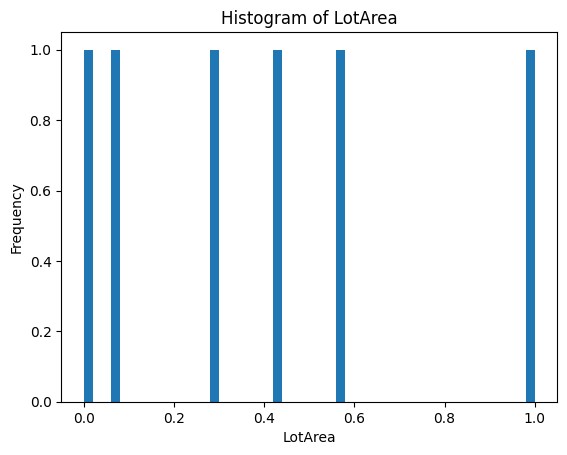

In [14]:
plot(min_max_normalized_series)

In [15]:
age = pd.Series([30,40,50,80,10,15])
age_min = age.min()
age_max = age.max()
new_max = 1
new_min = 0

# import MinMaxScaler
from sklearn.preprocessing import MinMaxScaler

# define the new min and max values
min_max_scaler = MinMaxScaler(feature_range=(new_min,new_max))

# fit the age data frame into the MinMaxScaler
min_max_scaler = min_max_scaler.fit(age.to_frame())

# transform the data with the new min, max and the data frame
min_max_df = pd.DataFrame(min_max_scaler.transform(age.to_frame()))
min_max_df

,0
0,0.285714
1,0.428571
2,0.571429
3,1.000000
4,0.000000
5,0.071429


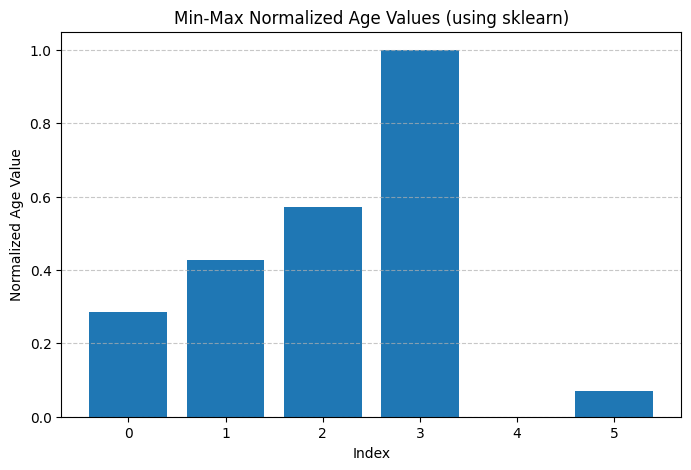

In [16]:
import matplotlib.pyplot as plt

def plot_bar(bar_df):

  plt.figure(figsize=(8, 5))
  plt.bar(bar_df.index, bar_df[0])
  plt.title('Min-Max Normalized Age Values (using sklearn)')
  plt.xlabel('Index')
  plt.ylabel('Normalized Age Value')
  plt.grid(axis='y', linestyle='--', alpha=0.7)
  plt.show()

plot_bar(min_max_df)

In [17]:
type(age)
type(age.to_frame())
3

3

In [18]:
# Min-max normalization can be done using a few lines via sklearn's MinMaxScaler
# that's a part of its preprocessing package
#
# It has two phases of usage, fit and transform -
#
# fit() is generally used to calculate and set the min-max values for the
# normalization phase
#
# transform() is generally used to transform a
#
# Prototype (parameters, default values):
# (feature_range: Any = (0, 1), *, copy: bool = True, clip: bool = False)
#
# feature_range is the range to which we wish to normalize
#
# copy when true does not do inplace replacement in the column values while
# running transform(...) by default, can be changed to false for inplace
# replacement
#
# clip when true, ensures that a new data point which wasn't passed to
# fit(...) for training, does not go beyond the range of the training data
minMaxScaler = MinMaxScaler(feature_range=(newMin, newMax))

# Calculates and sets variables for normalization
minMaxScaler.fit(A.to_frame())

# Performs the actual transformation on the data as np array
transformed_output = minMaxScaler.transform(A.to_frame())

# Converting the transformed column to do
transformed_column = pd.DataFrame(transformed_output)
transformed_column

,0
0,4.308561
1,4.840707
2,5.604221
3,4.817570
4,6.997055
...,...
1455,4.061922
1456,6.494987
1457,4.582500
1458,4.894847


In [19]:
# 2. Z-score normalization
#
# Z-score normalization is a normalization technique that takes into
# consideration mean as the center point and scales to the value/units of
# standard deviation (considers the general variance of the dataset).
#
# This kind of normalization is generally considered better because its less
# affected by outliers which would be a problem in case of min-max scaling
# as an unusual point that's very far would increase the scale to an extent
# that legitimate points within reasonable limits would be considered
# insignificant
#
# Mathematically, for every point 'a' in attribute set 'A',
# a_std = (a - A_mean / A_SD)

In [20]:
# Let us consider the LotArea column
A = df["LotArea"]

# Calculate the z-normalized value for column/series A
A_z_normalized = (A - A.mean()) / A.std()
A_z_normalized

,LotArea
0,-0.207071
1,-0.091855
2,0.073455
3,-0.096864
4,0.375020
...,...
1455,-0.260471
1456,0.266316
1457,-0.147760
1458,-0.080133


In [21]:
z_scaler = (age - age.mean()) / age.std()
z_scaler

,0
0,-0.292492
1,0.097497
2,0.487486
3,1.657452
4,-1.072469
5,-0.877475


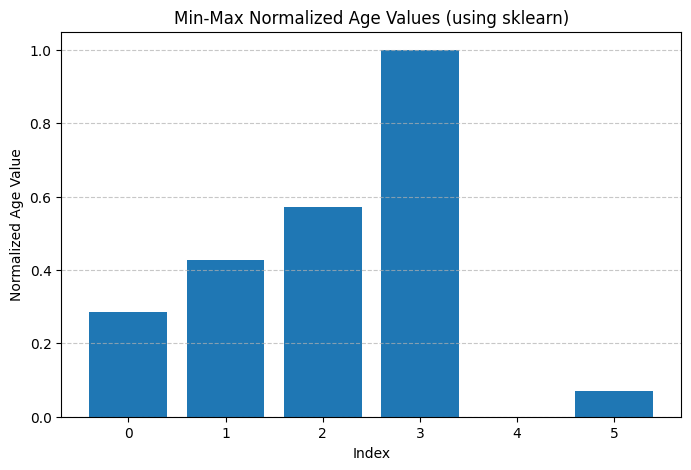

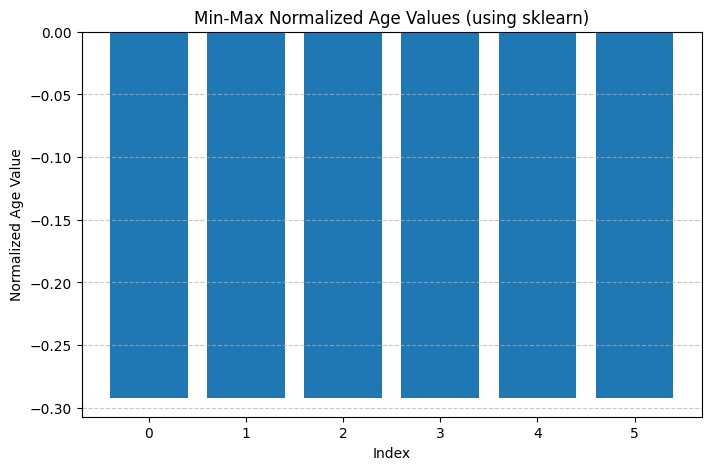

          0
0  0.285714
1  0.428571
2  0.571429
3  1.000000
4  0.000000
5  0.071429
0   -0.292492
1    0.097497
2    0.487486
3    1.657452
4   -1.072469
5   -0.877475
dtype: float64


In [22]:
plot_bar(min_max_df)
plot_bar(z_scaler)
print(min_max_df)
print(z_scaler)

In [23]:
# Sklearn's pre-processing package provides a function to perform this with some
# additional functionality which could be used for code simplicity
#
#
standard_scaler = StandardScaler()
A_z_normalized = standard_scaler.fit_transform(A.to_frame())
A_z_normalized

array([[-0.20714171],
       [-0.09188637],
       [ 0.07347998],
       ...,
       [-0.14781027],
       [-0.08016039],
       [-0.05811155]])

In [24]:
age = pd.Series([35, 65, 90])

# import StandardScaler
from sklearn.preprocessing import StandardScaler

z_scaler = StandardScaler()
# fit the age data frame into the MinMaxScaler
std_scaler = z_scaler.fit_transform(age.to_frame())

# transform the data with the new min, max and the data frame
std_scaler

age.mean()
age.std()
(35-60)/10
std_scaler

array([[-1.26012384],
       [ 0.07412493],
       [ 1.18599891]])

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def vis(df_input):
    """
    Generates four common plots for data visualization and insights:
    1. Histograms (with KDE) for numerical columns.
    2. Box plots for numerical columns.
    3. Count plots for categorical columns.
    4. Correlation heatmap for numerical columns.

    Args:
        df_input (pd.DataFrame): The input DataFrame.
    """

    print("--- Generating Plots for DataFrame Insights ---")

    numerical_cols = df_input.select_dtypes(include=['number']).columns
    categorical_cols = df_input.select_dtypes(include=['object', 'category', 'bool']).columns

    # 1. Histograms for numerical columns
    if not numerical_cols.empty:
        print("\nPlot 1: Histograms for Numerical Features")
        num_plots = len(numerical_cols)
        fig, axes = plt.subplots(nrows=num_plots, ncols=1, figsize=(10, 5 * num_plots))
        if num_plots == 1: # Handle single subplot case
            axes = [axes]
        for i, col in enumerate(numerical_cols):
            sns.histplot(df_input[col], kde=True, ax=axes[i])
            axes[i].set_title(f'Distribution of {col}')
            axes[i].set_xlabel(col)
            axes[i].set_ylabel('Frequency')
        plt.tight_layout()
        plt.show()
    else:
        print("\nNo numerical columns found for histograms.")


    # 2. Box plots for numerical columns
    if not numerical_cols.empty:
        print("\nPlot 2: Box Plots for Numerical Features")
        num_plots = len(numerical_cols)
        fig, axes = plt.subplots(nrows=num_plots, ncols=1, figsize=(10, 5 * num_plots))
        if num_plots == 1: # Handle single subplot case
            axes = [axes]
        for i, col in enumerate(numerical_cols):
            sns.boxplot(y=df_input[col], ax=axes[i])
            axes[i].set_title(f'Box Plot of {col}')
            axes[i].set_ylabel(col)
        plt.tight_layout()
        plt.show()
    else:
        print("\nNo numerical columns found for box plots.")


    # 3. Count plots for categorical columns
    if not categorical_cols.empty:
        print("\nPlot 3: Count Plots for Categorical Features")
        num_plots = len(categorical_cols)
        fig, axes = plt.subplots(nrows=num_plots, ncols=1, figsize=(10, 5 * num_plots))
        if num_plots == 1: # Handle single subplot case
            axes = [axes]
        for i, col in enumerate(categorical_cols):
            sns.countplot(y=df_input[col], ax=axes[i], order=df_input[col].value_counts().index)
            axes[i].set_title(f'Count Plot of {col}')
            axes[i].set_xlabel('Count')
            axes[i].set_ylabel(col)
        plt.tight_layout()
        plt.show()
    else:
        print("\nNo categorical columns found for count plots.")


    # 4. Correlation Heatmap for numerical columns
    if len(numerical_cols) > 1: # Need at least two for correlation
        print("\nPlot 4: Correlation Heatmap for Numerical Features")
        plt.figure(figsize=(12, 10))
        corr_matrix = df_input[numerical_cols].corr()
        sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
        plt.title('Correlation Matrix of Numerical Features')
        plt.show()
    elif len(numerical_cols) == 1:
        print(f"\nOnly one numerical column ('{numerical_cols[0]}') found. Skipping correlation heatmap.")
    else:
        print("\nNo numerical columns found for correlation heatmap.")

    print("\n--- Plotting Complete ---")

--- Generating Plots for DataFrame Insights ---

Plot 1: Histograms for Numerical Features


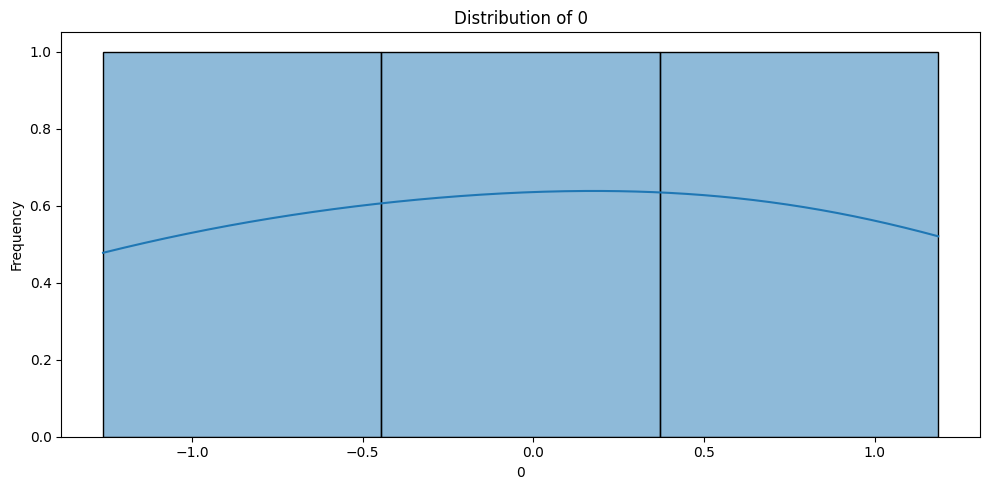


Plot 2: Box Plots for Numerical Features


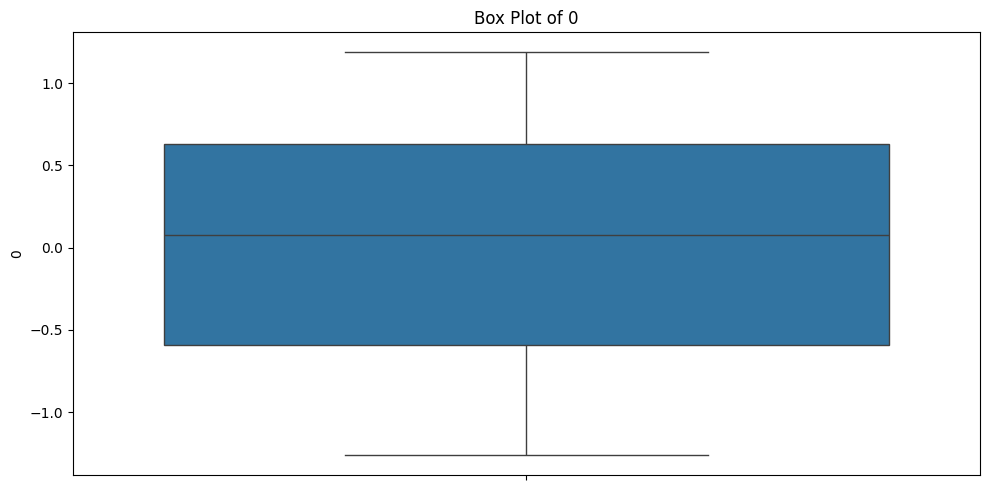


No categorical columns found for count plots.

Only one numerical column ('0') found. Skipping correlation heatmap.

--- Plotting Complete ---


In [26]:
vis(pd.DataFrame(std_scaler))

--- Generating Plots for DataFrame Insights ---

Plot 1: Histograms for Numerical Features


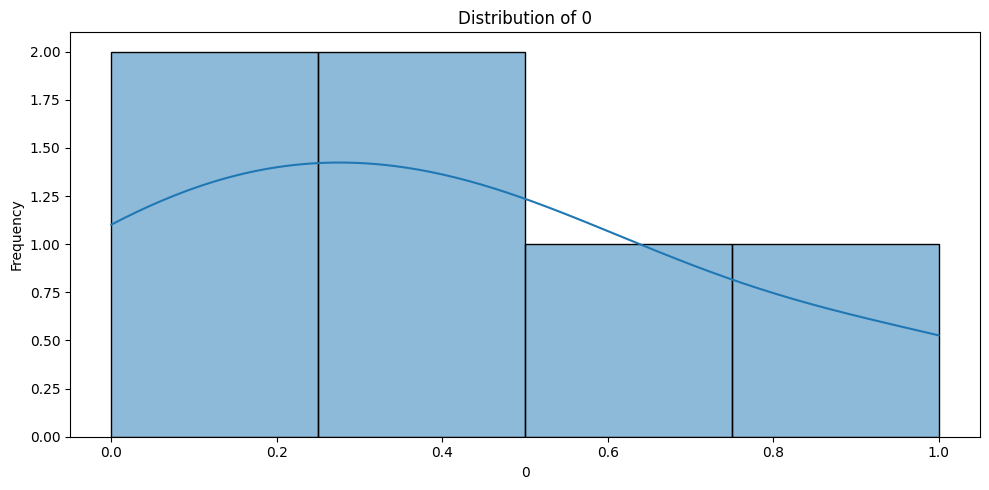


Plot 2: Box Plots for Numerical Features


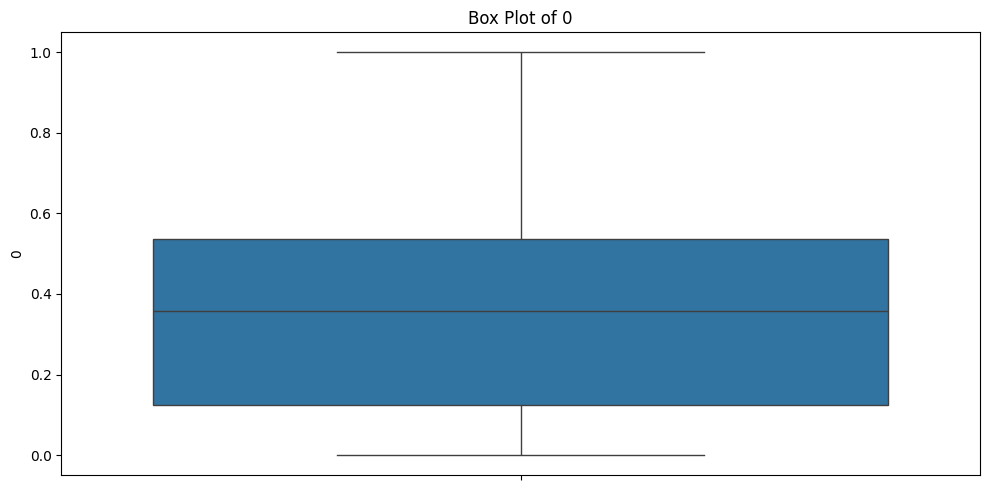


No categorical columns found for count plots.

Only one numerical column ('0') found. Skipping correlation heatmap.

--- Plotting Complete ---


In [27]:
vis(min_max_df)

In [28]:
# 3. Decimal Scaling Normalization
#
# Decimal Scaling Normalization is a form of normalization where we shift the
# decimal point of the number with respect the largest number in the dataset
# in terms of its absolute value, such that all numbers are between (-1, 1)
#
# We do so using the following steps:
#
# 1. To do so we first find the largest absolute number in the dataset
# 2. Calculate its number of digits (j)
# 3. Calculate 10^(j+1)
# 4. Divide the value obtained in step 3 to normalize it
#
# The value of such normalization is in the range -1 to 1 and by definition no
# value can be 1 or -1 (i.e. if the largest number is 1000, it implies that it
# would be normalized to 0.1 and not 1.0) [range exclusive]

In [29]:
# Let us consider the LotArea column again
A = df["LotArea"]

# Calculating the maximum absolute value of column/attribute A
maxAbsA = A.abs().max()
print(maxAbsA)

# Calculating the number of digits in the maximum absolute value of A
digitsMaxAbsA = math.floor(math.log(maxAbsA, 10)) + 1
print(digitsMaxAbsA)

A_dec_normalized = df["LotArea"] / 10**(digitsMaxAbsA + 1)
A_dec_normalized

215245
6


,LotArea
0,0.000845
1,0.000960
2,0.001125
3,0.000955
4,0.001426
...,...
1455,0.000792
1456,0.001318
1457,0.000904
1458,0.000972


In [30]:
# Let us consider the LotArea column again
A = age

# Calculating the maximum absolute value of column/attribute A
maxAbsA = A.abs().max()
print(f"Max absolute value (maxAbsA): {maxAbsA}")

# Calculating the number of digits in the integer part of the maximum absolute value of A
# This correctly identifies the number of digits before the decimal point for numbers >= 1.
digitsMaxAbsA = math.floor(math.log10(maxAbsA)) + 1 if maxAbsA >= 1 else 0
print(f"Number of digits (digitsMaxAbsA): {digitsMaxAbsA}")

# According to the lab's definition (values strictly between -1 and 1),
# the divisor should be 10^(digitsMaxAbsA + 1).
# If maxAbsA is 986 (digitsMaxAbsA=3), divisor is 10^4 = 10000.
# If maxAbsA is 1000 (digitsMaxAbsA=4), divisor is 10^5 = 100000 (to make 1000 -> 0.01, not 1.0).
j_val = digitsMaxAbsA + 1
divisor = 10**j_val
print(f"Divisor (10^j_val): {divisor}")

A_dec_normalized = A / divisor
A_dec_normalized

Max absolute value (maxAbsA): 90
Number of digits (digitsMaxAbsA): 2
Divisor (10^j_val): 1000


,0
0,0.035
1,0.065
2,0.090


In [31]:
# The last method as it appears isn't widely used, therefore there are no
# standard popular libraries that implement it

In [32]:
#implementing decimal scaling
import math

age = pd.Series([915, -986, 50, 60, 0.90])
max_abs_value = age.abs().max()
print(f"{max_abs_value=}")

total_digits = len(str(max_abs_value))
print(f"{total_digits=}")

decimal_scaler = age / math.pow(10, total_digits)
decimal_scaler

max_abs_value=986.0
total_digits=5


,0
0,0.009150
1,-0.009860
2,0.000500
3,0.000600
4,0.000009


--- Generating Plots for DataFrame Insights ---

Plot 1: Histograms for Numerical Features


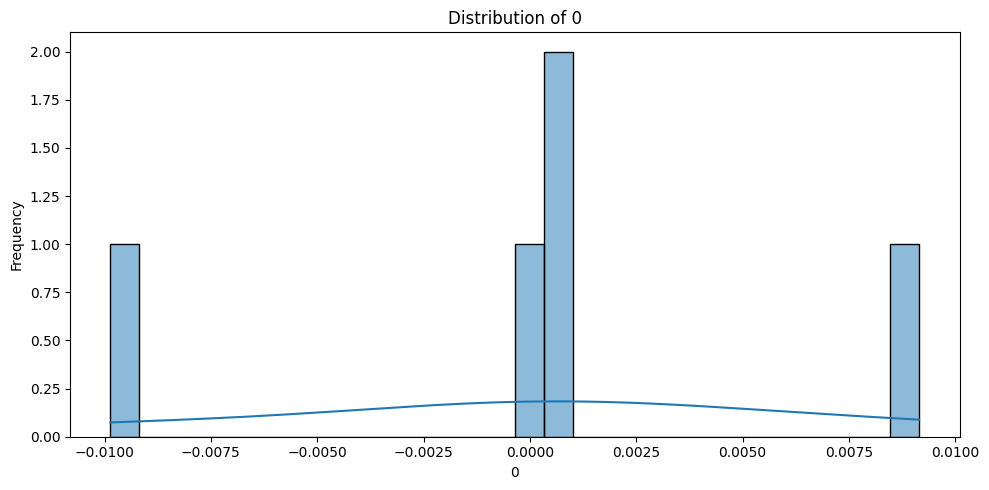


Plot 2: Box Plots for Numerical Features


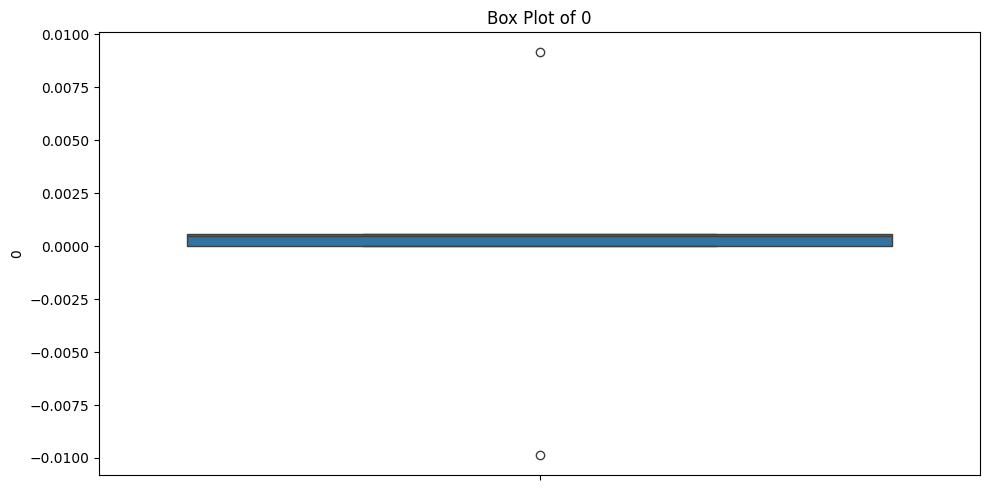


No categorical columns found for count plots.

Only one numerical column ('0') found. Skipping correlation heatmap.

--- Plotting Complete ---


In [33]:
vis(pd.DataFrame(decimal_scaler))

In [34]:
df.to_excel('final_dataset.xlsx',index=False)

In [35]:
df

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


In [36]:
import datetime, pytz; 
print("Current Time in IST:", datetime.datetime.now(pytz.utc).astimezone(pytz.timezone('Asia/Kolkata')).strftime('%Y-%m-%d %H:%M:%S'))

Current Time in IST: 2026-08-10 16:52:43
